# RACE — Exploratory Data Analysis

This notebook walks through the RACE dataset that drives the project: passage length distributions, answer label balance, question-type counts (Wh-word categories), and option-length statistics. Run from the project root after `python -m src.preprocessing` so processed CSVs are available.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
project_root = ROOT if (ROOT / 'src').exists() else ROOT.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import OPTION_LABELS, PROCESSED_DIR, preprocess_all
from src.question_generation import _classify_answer
from src.model_a_train import wh_label

if not (PROCESSED_DIR / 'train.csv').exists():
    preprocess_all()

train_df = pd.read_csv(PROCESSED_DIR / 'train.csv').fillna('')
val_df = pd.read_csv(PROCESSED_DIR / 'validation.csv').fillna('')
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv').fillna('')

summary = {
    'train_rows': len(train_df),
    'val_rows': len(val_df),
    'test_rows': len(test_df),
}
print(json.dumps(summary, indent=2))
train_df.head()

{
  "train_rows": 70292,
  "val_rows": 8787,
  "test_rows": 8787
}


,id,article,question,A,B,C,D,answer
0,high19299.txt,A man enters a store to buy milk. He walks out...,"When asked to do something complicated, men .","only use the ""reason"" side of the brain","only use the ""creative"" side of the brain",use different parts of the brain,use one part of the brain,D
1,middle6304.txt,"Forty years ago, I was in Grade One. One day,I...",The girl learned from her father _ .,how to be a good student,how to draw in different colors,the difference between sharing and giving,the importance of drawing in different colors,C
2,high11848.txt,Volunteering can help you deal with stress and...,What is the text mainly about?,How to be a good volunteer.,What we can do when we grow up.,What kind of volunteering one can do.,How to improve society by volunteering.,C
3,high10527.txt,There are two types of people in the world. Al...,How does the writer tell the happy from the un...,According to their degree of health.,According to their wealth.,According to their attitudes to the same thing.,According to their habits.,C
4,high23618.txt,"More than 6,000 children were expelled from US...",From the passage we can infer that in the US s...,most of students like shooting,the students are not expected to be soldiers,safety is actually a serious problem,students can freely take guns into their class...,C


## Passage length distribution

count    70292.0
mean       275.1
std         98.1
min          2.0
25%        216.0
50%        279.0
75%        326.0
max       1162.0
Name: article, dtype: float64


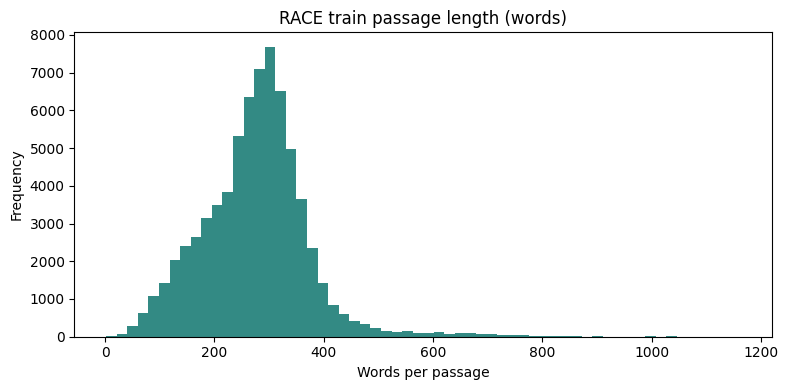

In [2]:
passage_lengths = train_df['article'].astype(str).str.split().map(len)
print(passage_lengths.describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(passage_lengths, bins=60, color='#0f766e', alpha=0.85)
ax.set_title('RACE train passage length (words)')
ax.set_xlabel('Words per passage')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Answer label balance

        train  validation   test
answer                          
A       21.75       21.62  22.25
B       25.90       26.08  25.33
C       27.14       26.99  27.76
D       25.20       25.30  24.66


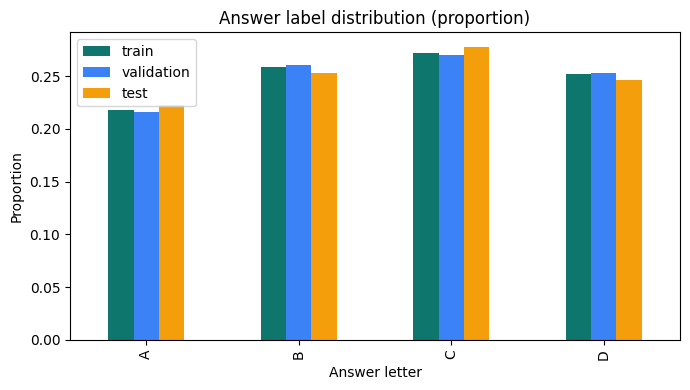

In [3]:
label_counts = pd.DataFrame({
    'train': train_df['answer'].value_counts(normalize=True).reindex(list(OPTION_LABELS), fill_value=0.0),
    'validation': val_df['answer'].value_counts(normalize=True).reindex(list(OPTION_LABELS), fill_value=0.0),
    'test': test_df['answer'].value_counts(normalize=True).reindex(list(OPTION_LABELS), fill_value=0.0),
})
print((label_counts * 100).round(2))

ax = label_counts.plot(kind='bar', figsize=(7, 4), color=['#0f766e', '#3b82f6', '#f59e0b'])
ax.set_title('Answer label distribution (proportion)')
ax.set_ylabel('Proportion')
ax.set_xlabel('Answer letter')
plt.tight_layout()
plt.show()

## Question type (Wh-word) counts

          train  validation  test
question                         
other     33885        4164  4254
what      14559        1811  1808
which      9760        1259  1230
why        3471         460   431
when       3044         381   376
how        2767         363   371
who        1774         226   215
where      1032         123   102


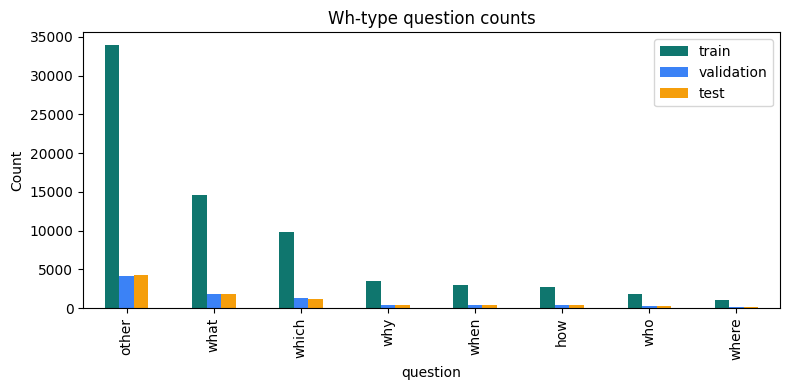

In [4]:
wh_train = train_df['question'].map(wh_label).value_counts()
wh_val = val_df['question'].map(wh_label).value_counts()
wh_test = test_df['question'].map(wh_label).value_counts()
combined = pd.DataFrame({'train': wh_train, 'validation': wh_val, 'test': wh_test}).fillna(0).astype(int)
print(combined)

ax = combined.plot(kind='bar', figsize=(8, 4), color=['#0f766e', '#3b82f6', '#f59e0b'])
ax.set_title('Wh-type question counts')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Option length statistics

          count  mean  std  min  25%  50%  75%    max
letter                                               
A       70292.0   5.4  3.3  0.0  3.0  5.0  8.0   91.0
B       70292.0   5.6  3.4  1.0  3.0  5.0  8.0  105.0
C       70292.0   5.8  3.5  1.0  3.0  6.0  8.0   48.0
D       70292.0   5.9  3.6  0.0  3.0  6.0  8.0   67.0


C:\Users\rayan.DESKTOP-59MFCDO\AppData\Local\Temp\ipykernel_5856\875391951.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_letter, labels=list(OPTION_LABELS), showfliers=False)


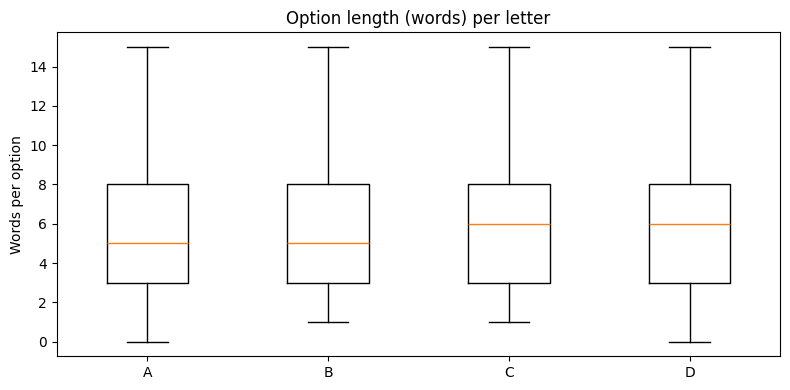

In [5]:
option_lengths = (
    train_df.melt(id_vars=['answer'], value_vars=list(OPTION_LABELS), var_name='letter', value_name='text')
    .assign(words=lambda d: d['text'].astype(str).str.split().str.len())
)
print(option_lengths.groupby('letter')['words'].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
data_per_letter = [option_lengths.loc[option_lengths['letter'] == letter, 'words'] for letter in OPTION_LABELS]
ax.boxplot(data_per_letter, labels=list(OPTION_LABELS), showfliers=False)
ax.set_title('Option length (words) per letter')
ax.set_ylabel('Words per option')
plt.tight_layout()
plt.show()

## Heuristic answer-type taxonomy

Quick sanity check on what kinds of answers RACE asks for, using `_classify_answer` from the question-generation module. The categories below mirror the Wh-word templates used by Model A's question generator.

what     2261
who      1817
where     629
how       202
when       91
Name: count, dtype: int64


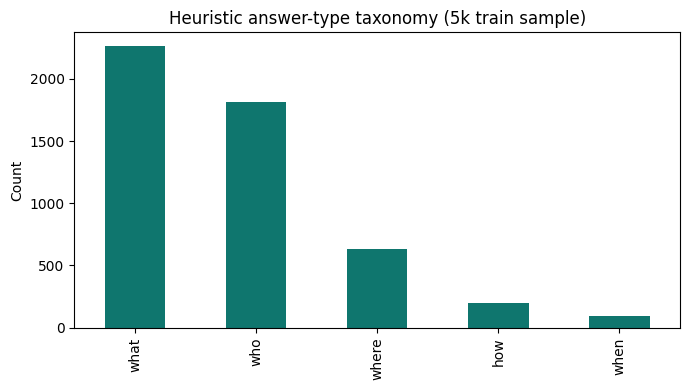

In [6]:
def answer_type(row):
    answer_letter = str(row['answer']).strip().upper()
    if answer_letter not in OPTION_LABELS:
        return 'other'
    return _classify_answer(str(row[answer_letter]), str(row.get('article', ''))[:200].lower())

answer_types = train_df.head(5000).apply(answer_type, axis=1).value_counts()
print(answer_types)

ax = answer_types.plot(kind='bar', figsize=(7, 4), color='#0f766e')
ax.set_title('Heuristic answer-type taxonomy (5k train sample)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Take-aways

- Passages average ~250–350 words and skew right; the long tail informs `max_features` choices for TF-IDF and Word2Vec sentence caps.
- Answer labels are roughly balanced across A/B/C/D (random baseline ~25%); large gaps would indicate a leakage shortcut, which we do not see.
- Wh-type counts skew toward `what` and `which`, with a long tail of `other`; the project's Wh-template generator covers the dominant categories.
- Option length varies more on D than on A, which the verifier's `option_len` feature captures.